In [2]:
import sys
import warnings

sys.path.append("../..")
warnings.filterwarnings(action="ignore")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange

from claymodel.datamodule import ClayDataModule
from claymodel.module import ClayMAEModule

In [4]:
data_dir = "./data/sentinel-2-l2a/"
checkpoint_path = "./clay-v1.5.ckpt"
metadata_path = "./configs/metadata.yaml"
chip_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mask_ratio = 0.7  # 70% masking of inputs

MODEL

In [5]:
module = ClayMAEModule.load_from_checkpoint(
    checkpoint_path=checkpoint_path,
    model_size="large",
    metadata_path=metadata_path,
    dolls=[16, 32, 64, 128, 256, 768, 1024],
    doll_weights=[1, 1, 1, 1, 1, 1, 1],
    mask_ratio=mask_ratio,
    shuffle=True,
)

module.eval();

In [7]:
# Distributed setup

import os
import torch.distributed as dist

if not dist.is_initialized():
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12359"
    dist.init_process_group("gloo", rank=0, world_size=1)

DATAMODULE

In [8]:
# load claydatamodule

# for model trainings, we stack chips from one sensor into batches of size 128.
# This reduces the num_workers we need to load the batches and speeds up the training process.
# although the batch size is 1, the data modeule reads batch of size 128.

dm = ClayDataModule(
    data_dir=data_dir,
    metadata_path=metadata_path,
    platforms=["sentinel-2-l2a"],
    size=chip_size,
    batch_size=1,
    num_workers=1,
)

dm.setup(stage="fit")

Total number of chips: 65


In [9]:
# ok to use either train or val dataloader

dl = iter(dm.train_dataloader())

In [10]:
s2 = next(dl)

In [11]:
# Assuming `naip` is already loaded as a dict-like object from your .npz
print(
    f"{s2['platform'][0]:<15}",
    s2["pixels"].shape,
    s2["time"].shape,
    s2["latlon"].shape,
)

sentinel-2-l2a  torch.Size([128, 4, 64, 64]) torch.Size([128, 4]) torch.Size([128, 4])


INPUT

In [12]:
def create_batch(chips, wavelengths, gsd, device):
    batch = {}

    batch["pixels"] = chips["pixels"].to(device)
    batch["time"] = chips["time"].to(device)
    batch["latlon"] = chips["latlon"].to(device)

    batch["waves"] = torch.tensor(wavelengths)
    batch["gsd"] = torch.tensor(gsd)

    return batch

FORWARD PASS

In [13]:
# creating batch for "NAIP"

platform = "sentinel-2-l2a"
metadata = dm.metadata[platform]
wavelengths = list(metadata.bands.wavelength.values())
gsd = metadata.gsd

In [15]:
batch_s2 = create_batch(s2, wavelengths, gsd, device)

In [17]:
with torch.no_grad():
    unmsk_patch, unmsk_idx, msk_idx, msk_matrix = module.model.encoder(batch_s2)
    pixels_s2, _ = module.model.decoder(
        unmsk_patch,
        unmsk_idx,
        msk_idx,
        msk_matrix,
        batch_s2["time"],
        batch_s2["latlon"],
        batch_s2["gsd"],
        batch_s2["waves"],
    )

In [18]:
def denormalize_image(normalized_images, means, stds):
    "Denormalizes an image using its mean & std"
    means = np.array(means)
    means = np.array(means).reshape(1, -1, 1, 1)
    stds = np.array(stds)
    stds = np.array(stds).reshape(1, -1, 1, 1)

    denormalized_images = normalized_images * stds + means
    return denormalized_images

In [19]:
s2_mean = list(dm.metadata["sentinel-2-l2a"].bands.mean.values())
s2_std = list(dm.metadata["sentinel-2-l2a"].bands.std.values())

batch_s2_pixels = batch_s2["pixels"].detach().cpu().numpy()
batch_s2_pixels = denormalize_image(batch_s2_pixels, s2_mean, s2_std)

Rearrange the patches from the decoder back into pixel space.

Output from Clay decoder is of shape: batch x patches x pixel_values_per_patch, we will reshape that to batch x channel x height x width



In [22]:
patch_size = 16
chip_size = 64
grid = chip_size // patch_size  # 4
num_spatial = grid * grid       # 16


In [23]:
# remove CLS, then keep only spatial tokens
spatial_tokens = unmsk_patch[:, 1 : 1 + num_spatial, :]


In [25]:
unmsk_embed_s2 = rearrange(
    spatial_tokens,
    "b (h w) d -> b d h w",
    h=grid,
    w=grid
)


In [26]:
denorm_pixels_s2 = denormalize_image(
    pixels_s2.cpu().detach().numpy(), s2_mean, s2_std
)
denorm_pixels_s2 = denorm_pixels_s2.astype(np.uint8)

ValueError: operands could not be broadcast together with shapes (128,64,256) (1,4,1,1) 

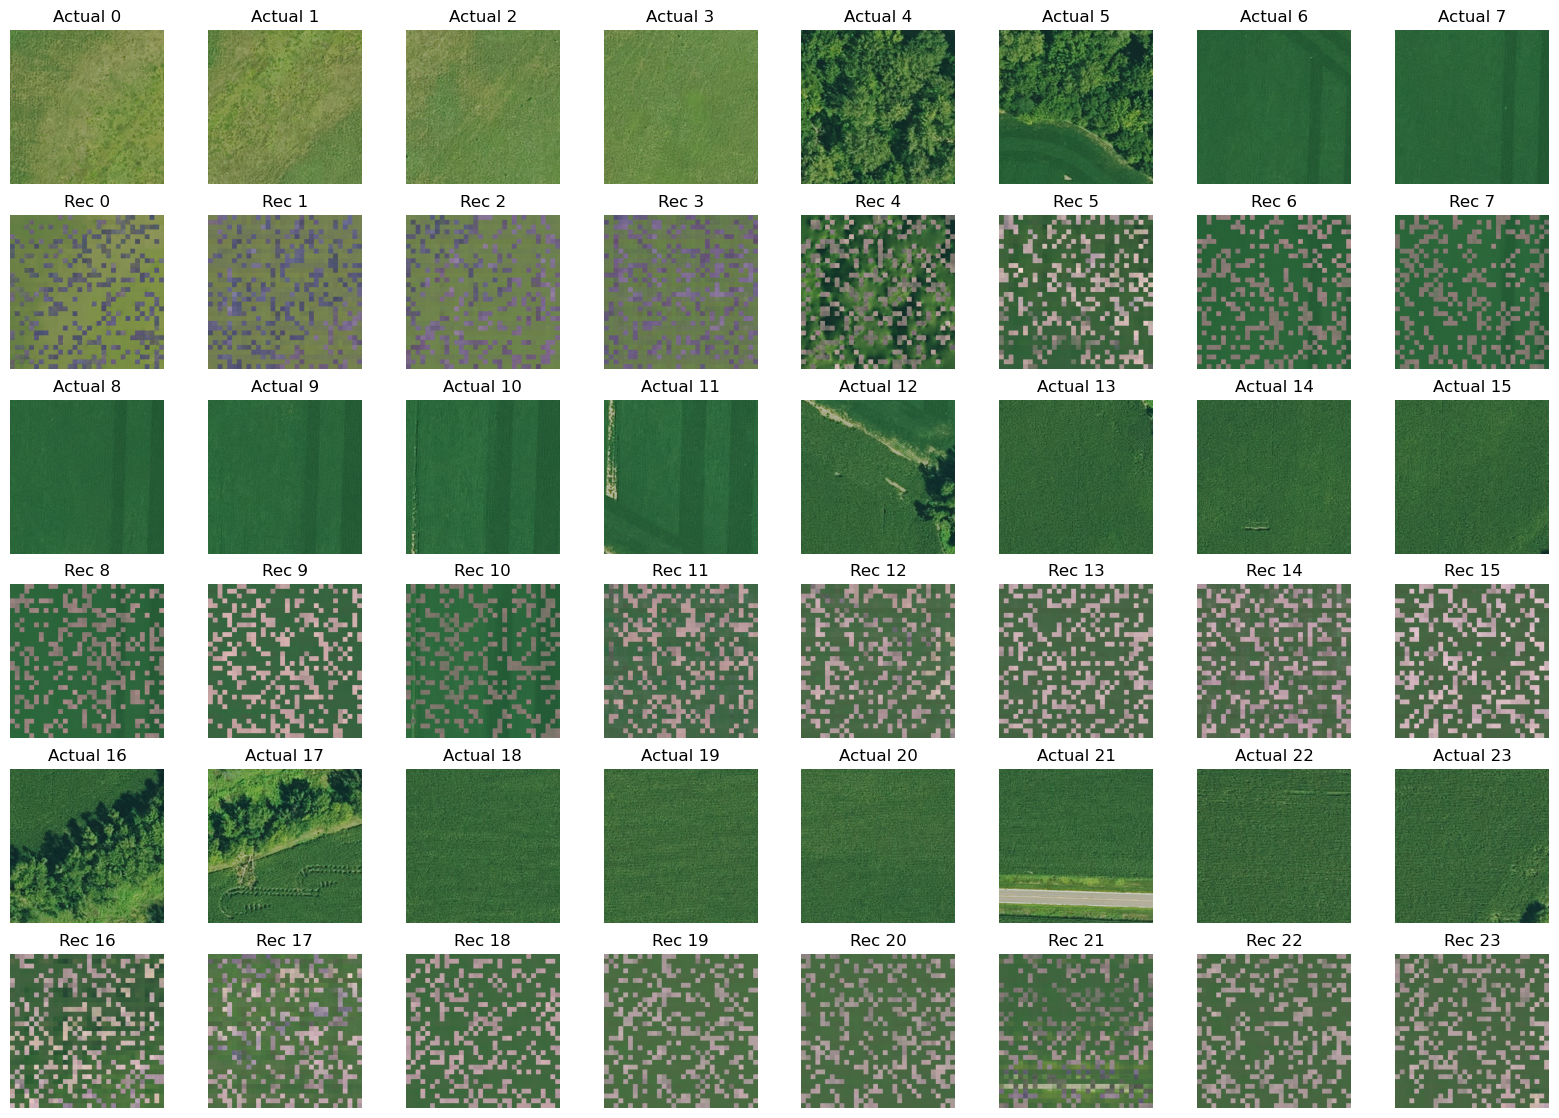

In [24]:
fig, axs = plt.subplots(6, 8, figsize=(20, 14))

for i in range(0, 6, 2):
    for j in range(8):
        idx = (i // 2) * 8 + j
        axs[i][j].imshow(batch_naip_pixels[idx, [0, 1, 2], ...].transpose(1, 2, 0))
        axs[i][j].set_axis_off()
        axs[i][j].set_title(f"Actual {idx}")
        axs[i + 1][j].imshow(denorm_pixels_naip[idx, [0, 1, 2], ...].transpose(1, 2, 0))
        axs[i + 1][j].set_axis_off()
        axs[i + 1][j].set_title(f"Rec {idx}")

In [25]:
print(unmsk_patch.shape)

torch.Size([128, 309, 1024])


In [27]:
print(denorm_pixels_naip.shape)

(128, 4, 256, 256)


In [28]:
print(pixels_naip.shape)

torch.Size([128, 4, 256, 256])


In [29]:
308 / 128

2.40625